<a href="https://colab.research.google.com/drive/1qaczIIow1CW2-xIe96HYe7rIkMF22OXr?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การสร้าง Decision Tree เพื่อทำนายอาการหัวใจล้มเหลว

<center>
  <img src="https://www.jcchouinard.com/wp-content/uploads/2021/11/image-1-1024x929.png" width="500"><br>
  ภาพจาก: <a href="https://www.jcchouinard.com/decision-trees-in-machine-learning/">Decision Trees in Machine Learning, with Examples (Python)</a>
</center>

## เตรียมข้อมูล

* เชื่อมต่อ Google Drive
* upload ไฟล์ heart.csv
* DecisionTreeClassifier ของ scikit-learn จะสร้าง Binary Tree Classifier
* ข้อมูลที่ใช้จะต้องเปลี่ยนจาก Category เป็น Numeric

| Name | Description | Valuea |
|------|-------------|--------|
| Age | age of the patient | [years] |
| Sex | sex of the patient | [M: Male, F: Female] |
| ChestPainType | chest pain type | [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic] |
| RestingBP | resting blood pressure | [mm Hg] |
| Cholesterol | serum cholesterol | [mm/dl] |
| FastingBS | fasting blood sugar | [1: if FastingBS > 120 mg/dl, 0: otherwise] |
| RestingECG | resting electrocardiogram results | [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria] |
| MaxHR | maximum heart rate achieved | [Numeric value between 60 and 202] |
| ExerciseAngina | exercise-induced angina | [Y: Yes, N: No] |
| Oldpeak | oldpeak = ST | [Numeric value measured in depression] |
| ST_Slope | the slope of the peak exercise ST segment | [Up: upsloping, Flat: flat, Down: downsloping] |
| HeartDisease | output class | [1: heart disease, 0: Normal] |

* สร้าง DataFrame จากไฟล์ heart.csv

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# แก้ไข path ใน pd.read_csv('')
heart_df = pd.read_csv('/content/drive/MyDrive/ML dataset/heart.csv')
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


* สำรวจข้อมูล

In [ ]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
heart_df.describe(include='O')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


## Preprocessing

* สร้าง DataFrame ของชุดข้อมูลที่สามารถนำไปใช้ได้

In [ ]:
# สร้าง list ของชื่อคอลัมน์ที่เป็น categorical
cat_features = ['ChestPainType',	'RestingECG',	'ST_Slope']

# ลบ column ที่เดี๋ยวจะแปลงค่าภายหลังออกก่อน
heart_enc = heart_df.drop(cat_features, axis=1) #ไม่ได้แก้ไข heart_df ต้นฉบับ
heart_enc

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
0,40,M,140,289,0,172,N,0.0,0
1,49,F,160,180,0,156,N,1.0,1
2,37,M,130,283,0,98,N,0.0,0
3,48,F,138,214,0,108,Y,1.5,1
4,54,M,150,195,0,122,N,0.0,0
...,...,...,...,...,...,...,...,...,...
913,45,M,110,264,0,132,N,1.2,1
914,68,M,144,193,1,141,N,3.4,1
915,57,M,130,131,0,115,Y,1.2,1
916,57,F,130,236,0,174,N,0.0,1


In [ ]:
heart_enc.drop(['HeartDisease'], axis=1, inplace=True) # มีผลกับข้อมุล heart_enc ต้นฉบับเลย
heart_enc.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
0,40,M,140,289,0,172,N,0.0
1,49,F,160,180,0,156,N,1.0
2,37,M,130,283,0,98,N,0.0
3,48,F,138,214,0,108,Y,1.5
4,54,M,150,195,0,122,N,0.0


* แปลง Category เป็น Numeric โดยใช้ Series.map()

In [ ]:
# เนื่องจาก Sex และ ExerciseAngina มีแค่ 2 ค่า ไม่จำเป็นต้องใช้ OneHotEncoder สามารถใช้คำสั่ง map ได้
heart_enc['Sex'] = heart_enc['Sex'].map({'M':0, 'F':1})
heart_enc.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
0,40,0,140,289,0,172,N,0.0
1,49,1,160,180,0,156,N,1.0
2,37,0,130,283,0,98,N,0.0
3,48,1,138,214,0,108,Y,1.5
4,54,0,150,195,0,122,N,0.0


In [ ]:
heart_enc['ExerciseAngina'] = heart_enc['ExerciseAngina'].map({'N':0, 'Y':1})
heart_enc.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
0,40,0,140,289,0,172,0,0.0
1,49,1,160,180,0,156,0,1.0
2,37,0,130,283,0,98,0,0.0
3,48,1,138,214,0,108,1,1.5
4,54,0,150,195,0,122,0,0.0


* แปลง Category เป็น Numeric โดยใช้ OneHotEncoder จาก sklearn.preprocessing

`from sklearn.preprocessing import OneHotEncoder`

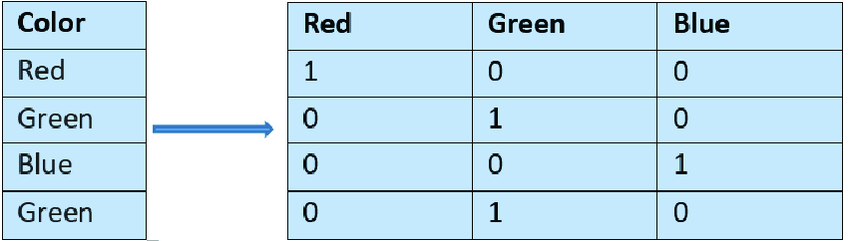

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder()
tmp = encoder.fit_transform(heart_df[cat_features]) # แปลงแต่ละค่าของ column ให้กลายเป็น one-hot vector ผลลัพธ์จะได้เป็น sparse matrix
tmp.toarray() # แปลง sparse matrix → dense array

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 1.]])

In [ ]:
# รายการค่าที่เป็นไปได้ในแต่ละ feature ที่ OneHotEncoder เรียนรู้หลังจาก fit()
# ใช้ดูว่าแต่ละ feature มี category อะไรบ้าง
encoder.categories_

[array(['ASY', 'ATA', 'NAP', 'TA'], dtype=object),
 array(['LVH', 'Normal', 'ST'], dtype=object),
 array(['Down', 'Flat', 'Up'], dtype=object)]

In [ ]:
# นำข้อมูลที่ transform แล้ว ไปใส่เพิ่มใน df
# สร้าง list ที่รวมชื่อ feature และชื่อ category ไว้ด้วยกัน
features = [col+'-'+cat
            for col, cats in zip(cat_features, encoder.categories_)
            for cat in cats]
features

['ChestPainType-ASY',
 'ChestPainType-ATA',
 'ChestPainType-NAP',
 'ChestPainType-TA',
 'RestingECG-LVH',
 'RestingECG-Normal',
 'RestingECG-ST',
 'ST_Slope-Down',
 'ST_Slope-Flat',
 'ST_Slope-Up']

In [ ]:
# เพิ่ม column ใน heart_enc
heart_enc[features] =tmp.toarray()
heart_enc

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType-ASY,ChestPainType-ATA,ChestPainType-NAP,ChestPainType-TA,RestingECG-LVH,RestingECG-Normal,RestingECG-ST,ST_Slope-Down,ST_Slope-Flat,ST_Slope-Up
0,40,0,140,289,0,172,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,1,160,180,0,156,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,0,130,283,0,98,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,1,138,214,0,108,1,1.5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,0,150,195,0,122,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1.2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68,0,144,193,1,141,0,3.4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57,0,130,131,0,115,1,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57,1,130,236,0,174,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
encoder.get_feature_names_out()

array(['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype=object)

In [ ]:
heart_enc[features] = pd.DataFrame(tmp.toarray(), columns=encoder.get_feature_names_out())
heart_enc

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType-ASY,ChestPainType-ATA,ChestPainType-NAP,ChestPainType-TA,RestingECG-LVH,RestingECG-Normal,RestingECG-ST,ST_Slope-Down,ST_Slope-Flat,ST_Slope-Up
0,40,0,140,289,0,172,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,1,160,180,0,156,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,0,130,283,0,98,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,1,138,214,0,108,1,1.5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,0,150,195,0,122,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1.2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68,0,144,193,1,141,0,3.4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57,0,130,131,0,115,1,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57,1,130,236,0,174,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# เปลี่ยน column class ให้ label เป็น text
heart_lbl = heart_df['HeartDisease'].map({1:'heart disease', 0:'normal'})
heart_lbl

,HeartDisease
0,normal
1,heart disease
2,normal
3,heart disease
4,normal
...,...
913,heart disease
914,heart disease
915,heart disease
916,heart disease


## แบ่งชุดข้อมูล Train และ Test

`from sklearn.model_selection import train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(heart_enc, heart_lbl, test_size=0.2, random_state=571)

In [ ]:
print(len(X_train), len(X_test))

734 184


## สร้าง Decision Tree
* import library เพื่อสร้าง tree

>`from sklearn.tree import DecisionTreeClassifier`

* สร้าง Tree เปล่า

>`DecisionTreeClassifier()`

* เรียนรู้ข้อมูล

>`fit(X, y)`







In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
# สร้าง tree เปล่า
classifier = DecisionTreeClassifier(random_state=571)

In [ ]:
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=571)

* ดูความลึกของ tree
```
get_depth()
```

In [ ]:
classifier.get_depth()

12

* วาด tree

In [ ]:
import matplotlib.pyplot as plt

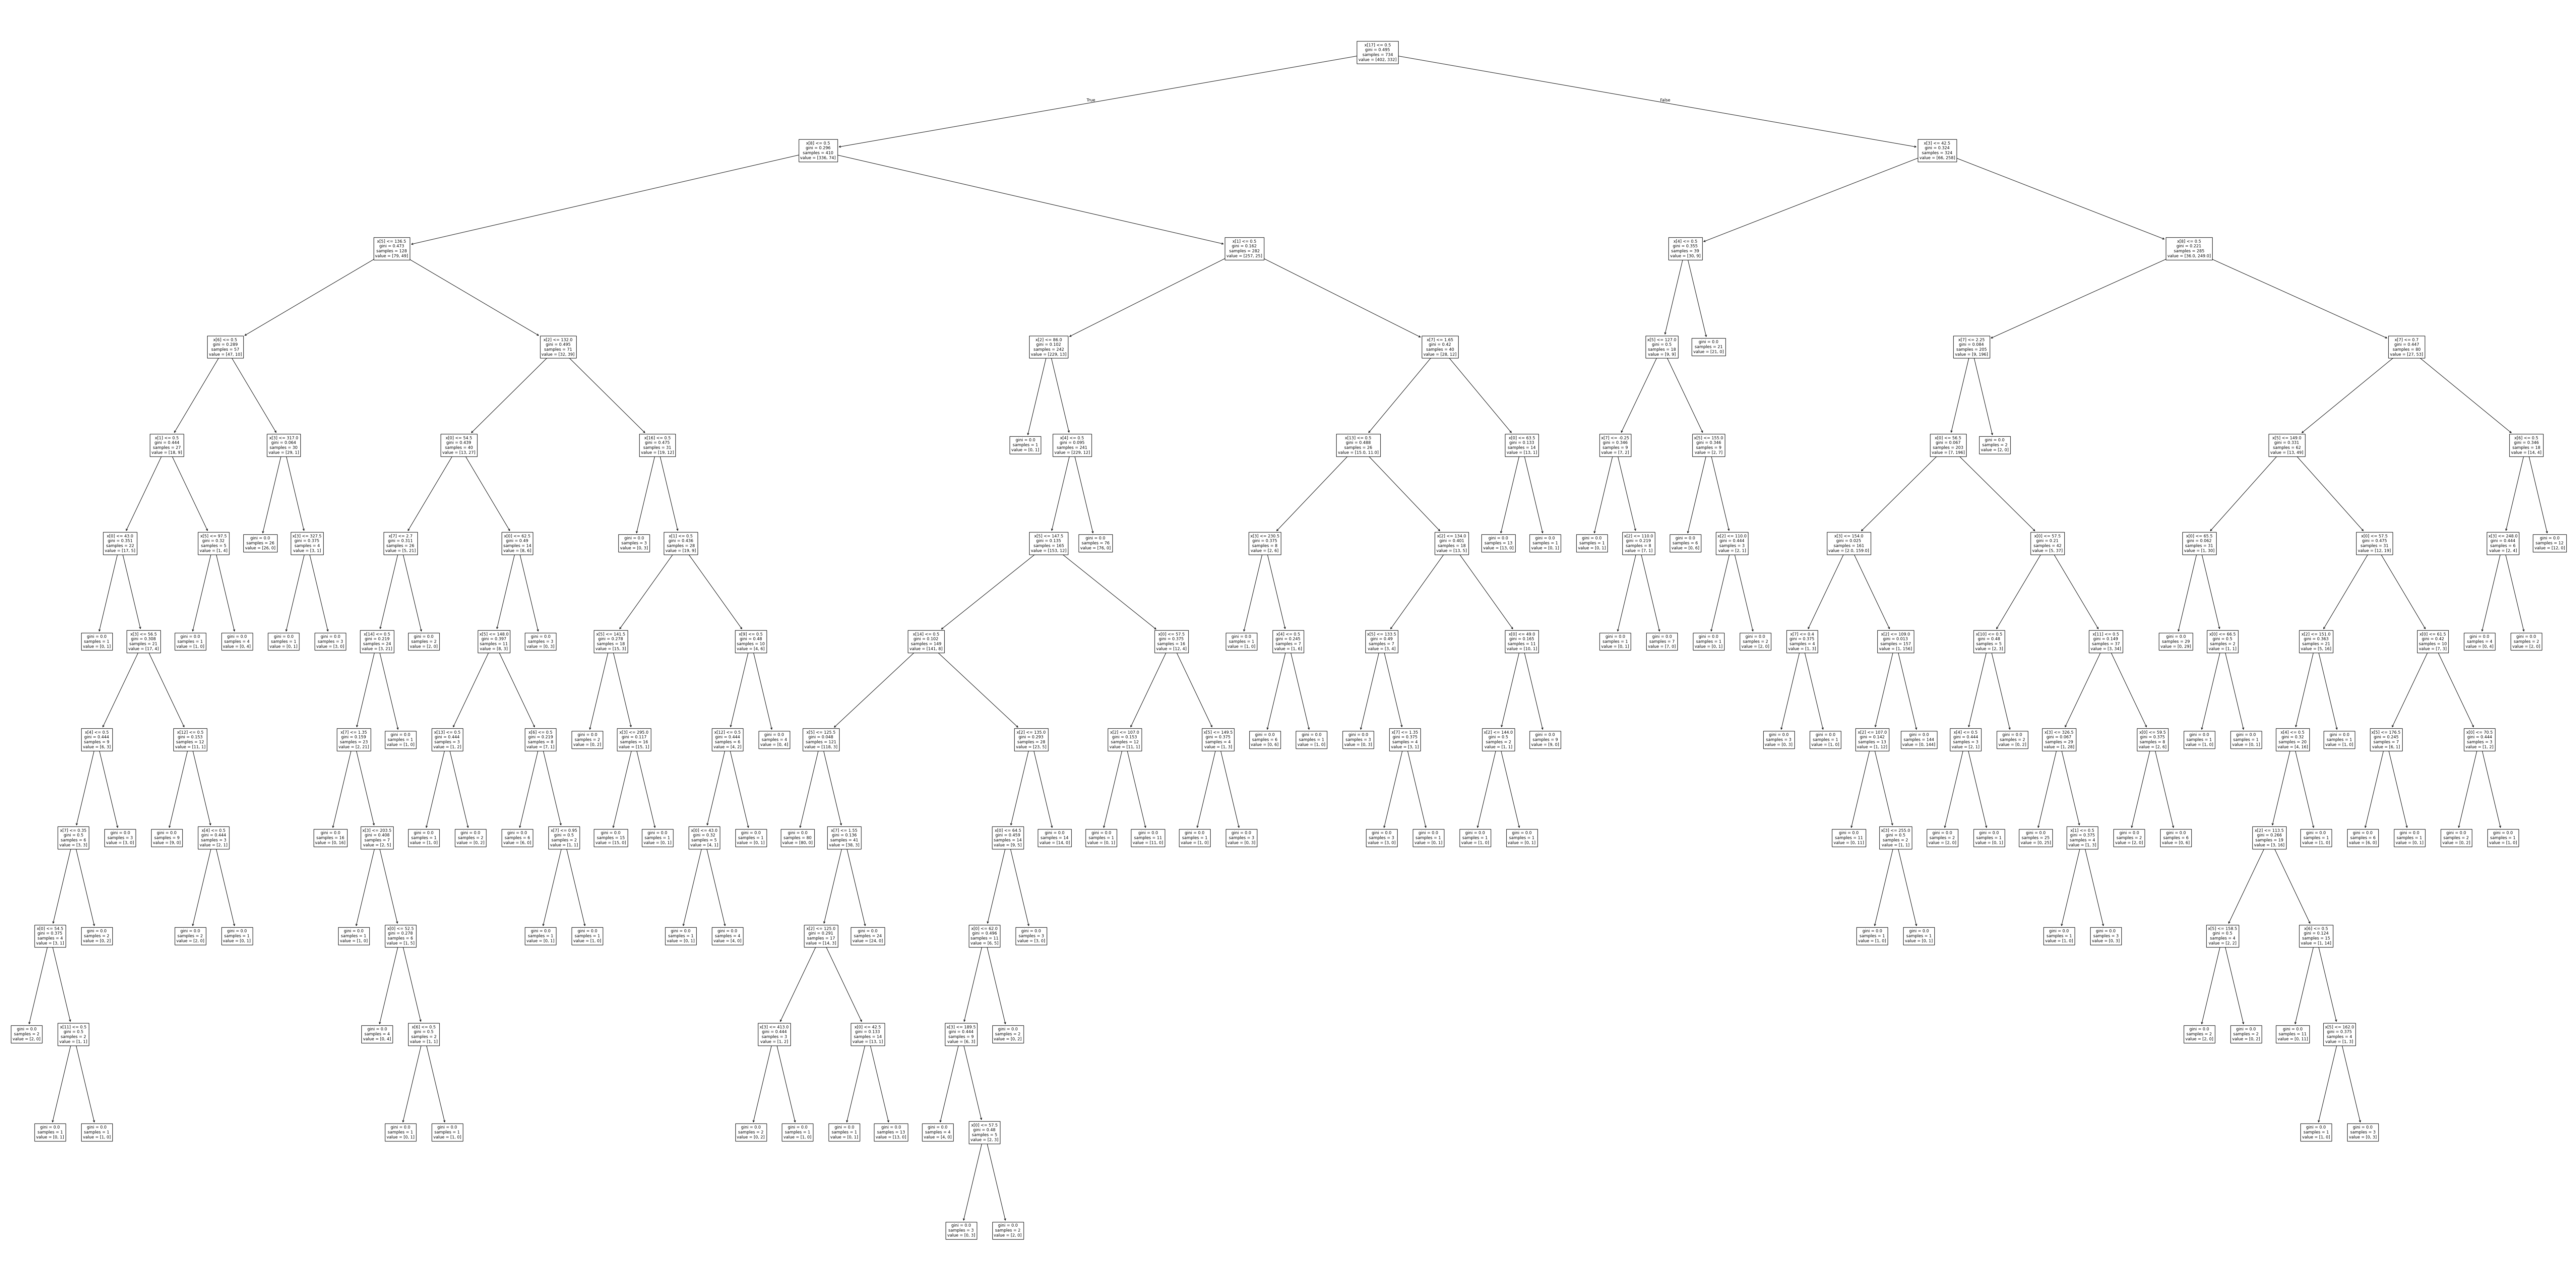

In [ ]:
plt.figure(figsize=(100, 50))
plot_tree(classifier)
plt.show()

## วัดประสิทธิภาพ

* ทำนายค่าจากชุดข้อมูล test

In [ ]:
y_predict = classifier.predict(X_test)
y_predict

array(['normal', 'normal', 'normal', 'normal', 'normal', 'normal',
       'heart disease', 'normal', 'normal', 'heart disease',
       'heart disease', 'normal', 'normal', 'normal', 'normal',
       'heart disease', 'heart disease', 'normal', 'normal', 'normal',
       'heart disease', 'heart disease', 'heart disease', 'normal',
       'normal', 'normal', 'normal', 'heart disease', 'normal', 'normal',
       'heart disease', 'heart disease', 'normal', 'normal', 'normal',
       'heart disease', 'normal', 'normal', 'heart disease',
       'heart disease', 'heart disease', 'normal', 'heart disease',
       'heart disease', 'normal', 'heart disease', 'heart disease',
       'normal', 'normal', 'normal', 'normal', 'normal', 'heart disease',
       'heart disease', 'heart disease', 'heart disease', 'heart disease',
       'heart disease', 'normal', 'heart disease', 'heart disease',
       'normal', 'heart disease', 'normal', 'normal', 'normal',
       'heart disease', 'heart disease', 'norm

* คำนวณ Confusion matrix

`from sklearn.metrics import classification_report`

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_predict))

               precision    recall  f1-score   support

heart disease       0.82      0.79      0.81       106
       normal       0.73      0.77      0.75        78

     accuracy                           0.78       184
    macro avg       0.78      0.78      0.78       184
 weighted avg       0.78      0.78      0.78       184



## ปรับความลึกของ Tree

* พิจารณาจากค่า accuracy
```
from sklearn.metrics import accuracy_score
```

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
for d in range(2,12):
  cl = DecisionTreeClassifier(random_state=571, max_depth=d)
  cl.fit(X_train, y_train)
  y_tmp = cl.predict(X_test)
  print(d, accuracy_score(y_test, y_tmp))

2 0.8260869565217391
3 0.8206521739130435
4 0.8206521739130435
5 0.8369565217391305
6 0.8315217391304348
7 0.8152173913043478
8 0.8152173913043478
9 0.8315217391304348
10 0.7989130434782609
11 0.7717391304347826


In [ ]:
classifier5 = DecisionTreeClassifier(random_state=571, max_depth=5)
classifier5.fit(X_train, y_train)
y_predict5 = classifier5.predict(X_test)
print(classification_report(y_test, y_predict5))

               precision    recall  f1-score   support

heart disease       0.86      0.86      0.86       106
       normal       0.81      0.81      0.81        78

     accuracy                           0.84       184
    macro avg       0.83      0.83      0.83       184
 weighted avg       0.84      0.84      0.84       184



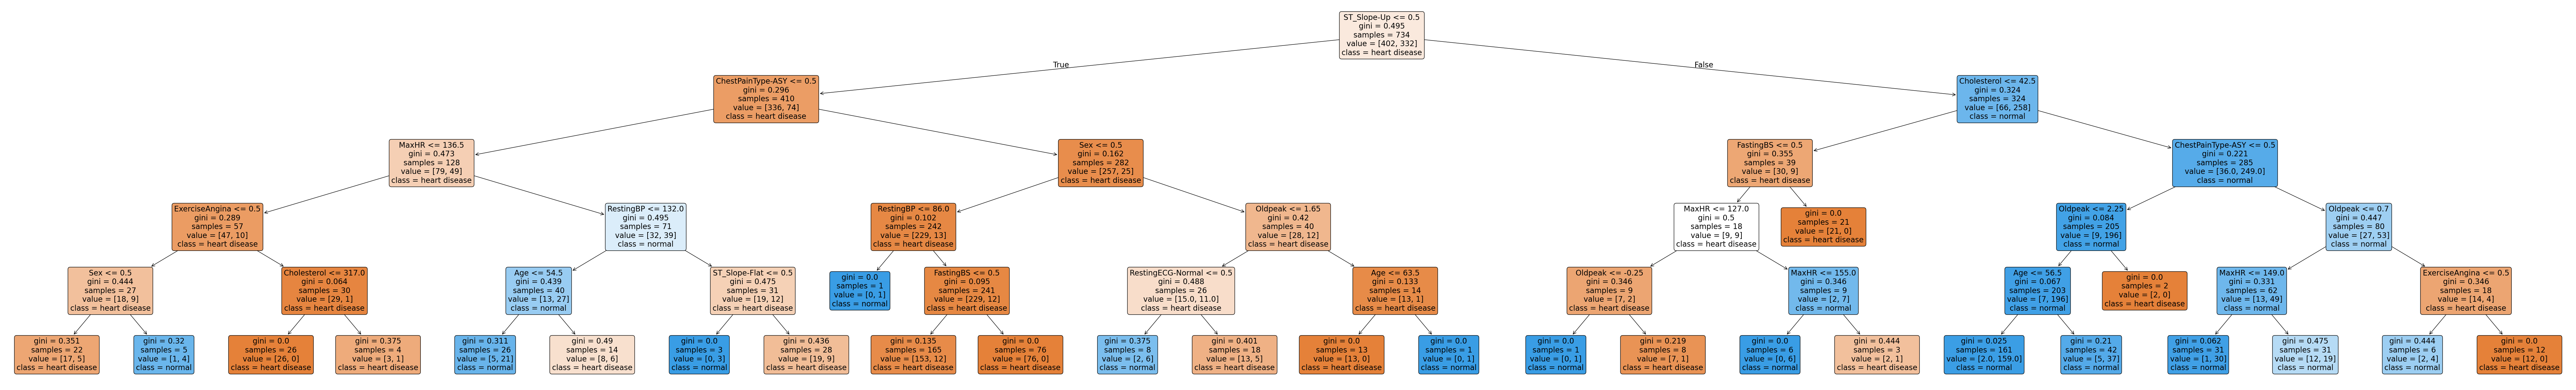

In [ ]:
plt.figure(figsize=(100, 15))
plot_tree(classifier5, feature_names=heart_enc.columns,
          class_names=classifier5.classes_, filled=True, rounded=True)
plt.show()

# Challenge: ทำนายข้อมูลผู้ป่วยรายใหม่

In [ ]:
new_patients = pd.read_csv('/content/drive/MyDrive/ML dataset/new_patients.csv')
new_patients

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,Y,0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1,Flat
2,37,M,ATA,130,283,0,ST,98,N,0,Up
3,38,M,ASY,110,196,0,ST,166,N,0,Flat
4,51,M,ATA,125,188,0,Normal,145,Y,0,Up
5,53,M,NAP,145,518,0,Normal,130,N,0,Flat
6,63,M,ASY,150,223,0,Normal,115,Y,0,Flat


In [ ]:
new_patients_enc = new_patients.copy()
new_patients_enc['Sex'] = new_patients_enc['Sex'].map({'M':0, 'F':1})
new_patients_enc['ExerciseAngina'] = new_patients_enc['ExerciseAngina'].map({'N':0, 'Y':1})
new_patients_enc[features] = pd.DataFrame(encoder.transform(new_patients_enc[cat_features]).toarray(), columns=features)
new_patients_enc.drop(cat_features, axis=1, inplace=True)

new_patients['predict'] = classifier5.predict(new_patients_enc)
new_patients

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,predict
0,40,M,ATA,140,289,0,Normal,172,Y,0,Up,normal
1,49,F,NAP,160,180,0,Normal,156,N,1,Flat,heart disease
2,37,M,ATA,130,283,0,ST,98,N,0,Up,normal
3,38,M,ASY,110,196,0,ST,166,N,0,Flat,heart disease
4,51,M,ATA,125,188,0,Normal,145,Y,0,Up,normal
5,53,M,NAP,145,518,0,Normal,130,N,0,Flat,heart disease
6,63,M,ASY,150,223,0,Normal,115,Y,0,Flat,heart disease
